# 2025-26 Points per Win

## Introduction

The concept is simple, score the most points and you win the game. But when NBA teams win games, do they score more than their average or do some teams have to reduce thier offensive output and focus on other aspects of the game in order to win? If a team is really good, then the assumption is that they likely blow away most competition with high scoring basketball. Perhaps it may be the other around, poorer teams may need to cultivate more effort than normal to pull out a win. But is that method sustainable?

## **Importing Packages and Gathering Raw Data**

### **Packages**
- <span style="color:#228B22">*leaguegamefinder*</span>, from nba_api - to gather raw nba data.
- <span style="color:#228B22">*pandas*</span> - For easier data wrangling and cleaning.
- <span style="color:#228B22">*matplotlib.pyplot*</span> - For visualizing data on a graph.
- <span style="color:#228B22">*OffsetImage and AnnotationBbox*</span> - For plotting team logos on bar graph.
- <span style="color:#228B22">*Image*</span> - For altering the sizes of the team and league logo. 
- <span style="color:#228B22">*os*</span> - For basic pathing functions.
- <span style="color:#228B22">*Path*</span> - From pathlib, for basic pathing functions.
- <span style="color:#228B22">*floor*</span> - From math, for getting the floor whole number of a float.
- <span style="color:#228B22">*Tuple*</span> - From typing, for type hinting a function output.

### **Gathering Data**
The leaguegamefinder function is used to gather summarized game data, including teams playing, scores, field goals made, fouls, etc. I used the season_nullable and season_type_nullable arguments to retreieve all regular season game data from the 2025-26 seasons. The function returned the data in a pandas dataframe. I wrote the data out to a csv, so that I could review the raw data.

In [1]:
from nba_api.stats.endpoints import leaguegamefinder
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.pyplot import Axes
import os
from PIL import Image
from pathlib import Path
import numpy as np
from math import floor
from typing import Tuple

csv_dir = 'csvs'

# Pull data from the 2025-2026 NBA season
games_26 = leaguegamefinder.LeagueGameFinder(season_nullable='2025-26', season_type_nullable='Regular Season')
# get data frame from returned list
df_26: pd.DataFrame = games_26.get_data_frames()[0]
# Write data to csv for easier viewing. Not necessary
df_26.to_csv(os.path.join(csv_dir,'25_26_season_raw_data.csv') ,index=False)

In [2]:
# 2025-26
team_stats_26 = df_26[['TEAM_ABBREVIATION', 'PTS', 'WL']]
# Write to csv for easy viewing
team_stats_26.to_csv(os.path.join(csv_dir,'26_season_filtered_points.csv'), index=False)

## Filtering and Manipulation

After collecting the data, only relevant columns are needed. 'TEAM_ABBREVIATION', 'GAME_ID', 'MATCHUP', 'WL', and 'PTS' are the only columns needed to determine points per win. For simplicity and easier callbacks, some of the columns will be renamed.

A new column named 'home/away' was created to determine where the 'team' was playing. In the 'MATCHUP', now named 'opp', column provides the indicator of whether a team was home or away. If '@' is in the cell, then the team is away, if 'vs' then the team is home. The pandas apply function was used to make those determinations. After home and away games are deciphered, the 'opp' column is sliced to only contain the opponent's name.

The dataframe contains two instances of each 'gameid', one for each team. A function that takes two arguments, 'opp' and 'gameid', was created to determine the points scored by the other team and add it to it's own column named 'opp_score'. The function was utilized in the pandas apply funciton.

In [3]:
# Aggregating Game data based off of the game ID
game_stats = df_26[['TEAM_ABBREVIATION', 'GAME_ID', 'MATCHUP' , 'WL', 'PTS' ]]
# New Names for easier call backs
name_dict = {
    'TEAM_ABBREVIATION': 'team',
    'GAME_ID': 'gameid',
    'MATCHUP': 'opp',
    'PTS': 'points',
}
game_stats = game_stats.rename(columns=name_dict)
# Create a new column that determines if the team was home or away
game_stats['home/away'] = game_stats["opp"].apply(lambda x: "away" if "@" in x else "home")
# Opp (opponent) comes from the 'matchup' column, slice sting to have the opponent team name.
game_stats['opp'] = game_stats['opp'].str[-3:]

# Function to be called in pandas apply function to determine the opponents score
def opp_score(x,y):
    # Search the dataframe for other row with the same game idea and the opp name
    score: int = game_stats['points'].loc[(game_stats['team']== x) & (game_stats['gameid']==y)].values[0]
    # return score
    return score
# Applying funciton to create new row with opponents score.
game_stats['opp_score'] = game_stats.apply(lambda x: opp_score(x['opp'], x['gameid']), axis = 1)
print(game_stats.head())

  team      gameid  opp WL  points home/away  opp_score
0  GSW  0022501199  LAC  L     110      away        115
1  NYK  0022501190  CHA  L      96      home        110
2  PHI  0022501191  MIL  W     126      home        106
3  DAL  0022501193  CHI  W     149      home        128
4  DEN  0022501197  SAS  W     128      away        118


## Aggregation

Now that the data is shaped to relevant columns, the data can now be aggregated to determine to points per win and other relevant data. Pandas built-in aggregate function was used to group the data by the team 3-letter abbreviation. 

1. First, the overall average, win or lose, was determined for the sake of comparison to points per win. This will help with determining if teams score more or less when they win.

2. A second dataframe ('wins_data') was created by filtering the 'game_stats' dataframe for every win that occured. From the new data frame, the league average per win was calculated to be used as a comparison tool later.

3. The 'wins_data' dataframe was aggregated to contain the average points per win and count the number wins each team had in the 2025-26 season.

The overall average and wins_data aggregate data was written to a csv for easy veiwing.

In [4]:
# Repeating the same steps performed previously, but for the 2025-26 season.
overall_avg = (
    game_stats.groupby('team')
    .agg(
        points=('points', 'mean'),
    )
).reset_index()

# Save Overall Average data to a csv
overall_avg.to_csv(os.path.join(csv_dir,'overall_avg.csv'), index=False)

# Filter Data frame for just the wins of each team
wins_data = game_stats[game_stats['WL'] == 'W']
# wins_data.to_csv(os.path.join(csv_dir,'wins_raw.csv'), index=False)
# print(wins_data.head())

# Determine the League Average for Points per Win
league_win_avg = sum(wins_data['points'])/len(wins_data['points'])

# Aggregate the Wins Data
wins_agg = (
    wins_data.groupby('team')
    .agg(
        points=('points', 'mean'), # Get the Average points scored per win
        wins=('WL', lambda s: (s=='W').sum()) # Count the Number of wins each team had in the 25-26 season
    )
).reset_index()
#wins_agg = wins_agg.rename(columns={'TEAM_ABBREVIATION':'teams'}) # Easier name to type when calling data.
print(wins_agg.head())

# Save Winning Average data to a csv
wins_agg.to_csv(os.path.join(csv_dir,'wins_avg.csv'), index=False)

  team      points  wins
0  ATL  123.521739    46
1  BKN  116.300000    20
2  BOS  120.446429    56
3  CHA  121.795455    44
4  CHI  125.000000    31


## Merging Data

Before merging the point per win dataframe and overall point per game dataframe, we need to rename each respective 'points' column. Changing the 'points' columns to a unique name will help with easy identification when the data is merged. The wins data is named 'win_points' and the overall data is named 'ovr_points'. The data is merged into a new dataframe named 'points_compare'. They are inner joined based on the team name.

Once the new merged dataframe is created, two new columsn are added. The first is 'p_diff' which represents the points differential between the points per win average and the overall points per game average. The second column is calculating the season win percentage for each team. Afterwards, the dataframe was sorted by 'p_diff' in ascending order.

In [5]:
# Before merging change the column names for points for the win data and overall data
win_merge = wins_agg.rename(columns={'points':'win_points'})
ovr_merge = overall_avg.rename(columns={'points':'ovr_points'})

# Run an inner join on the team names to align the win avg and overall avg properly
points_compare = pd.merge(win_merge, ovr_merge, how='inner', on=['team'])

# Determine the different between the winning average and the overall average
points_compare['p_diff'] = points_compare['win_points'] - points_compare['ovr_points']

# Determine the win percentage of each team for the 2025-26 season.
points_compare['win_pct'] = round(points_compare['wins']/82,3)
# Sort the data by the point differential (p_diff)
points_compare = points_compare.sort_values('p_diff', ascending=True)
print(points_compare.head())

   team  win_points  wins  ovr_points    p_diff  win_pct
10  HOU  118.307692    52  115.231707  3.075985    0.634
26  SAS  122.951613    62  119.829268  3.122345    0.756
7   DEN  125.296296    54  122.073171  3.223126    0.659
20  OKC  122.265625    64  119.024390  3.241235    0.780
8   DET  121.150000    60  117.768293  3.381707    0.732


In [27]:
def adjust_logo(logo_path: str, width:int = 50, height:int = 50)->OffsetImage:
    # Getting Name of Image file
    image_name = Path(logo_path).name
    # Opening the Image
    img = Image.open(logo_path)
    # altering size of image
    img.thumbnail(size=(width,height))
    image_adj = os.path.join('logos',image_name)
    # Saving the reduced Image
    img.save(image_adj, optimize=True, quality=85)
    # # Read image into Numpy array
    # new_img = plt.imread(image_adj)
    # # Adjust 'zoom' to scale your image up or down
    # imagebox = OffsetImage(new_img)

    # return imagebox # returning OffsetImage

In [30]:
images = ['NBA', 'BKN', 'OKC', 'UTA']
widths = [40, 40, 40, 40]
heights = [40, 40, 40, 40]
logo_src = os.path.join('..','logos', 'logo_src')
for i in range(len(images)):
    path = os.path.join(logo_src, f"{images[i]}_logo.png")
    adjust_logo(path, widths[i], heights[i])

In [49]:
def plot_nba_logo(ax: Axes, title_xy: tuple):
    # Path to NBA logo
    logo_path = os.path.join('logos', 'NBA_logo.png')
    # Read image into Numpy array
    img = plt.imread(logo_path)
    # Adjust 'zoom' to scale your image up or down
    imagebox = OffsetImage(img, zoom=1)
    # Places Logo on the bar graph next to the title.
    anno_box = AnnotationBbox(imagebox, xy=(0.265, 1.065), xycoords='axes fraction', 
                              box_alignment=(0, 1), frameon=False)
    ax.add_artist(anno_box)

## Points per Win vs Points per Game

Below, a double bar graph has been generated based off the previously compiled data. The graph displays each repspective team's average points per win and there average points per game. There is a black horizontal line to represent the league-wide average points per win so it can be easier to analyze how teams perform against the average. At first glance, the Utah Jazz and the Miami Heat's average points per win stands out the most by being really high. In the case of the Utah Jazz, there overall average points per game is much further below their average points per win compared to the Miami Heat's averages. Another standout is how poor the Brooklyn Nets's average point per win is. Not only does the Nets have the worst average points per win, they also have the worst points per game overall. not even reaching 110 points per game. Both the Jazz and the Nets were one of the worst teams in the league in the 2025-26 NBA season.

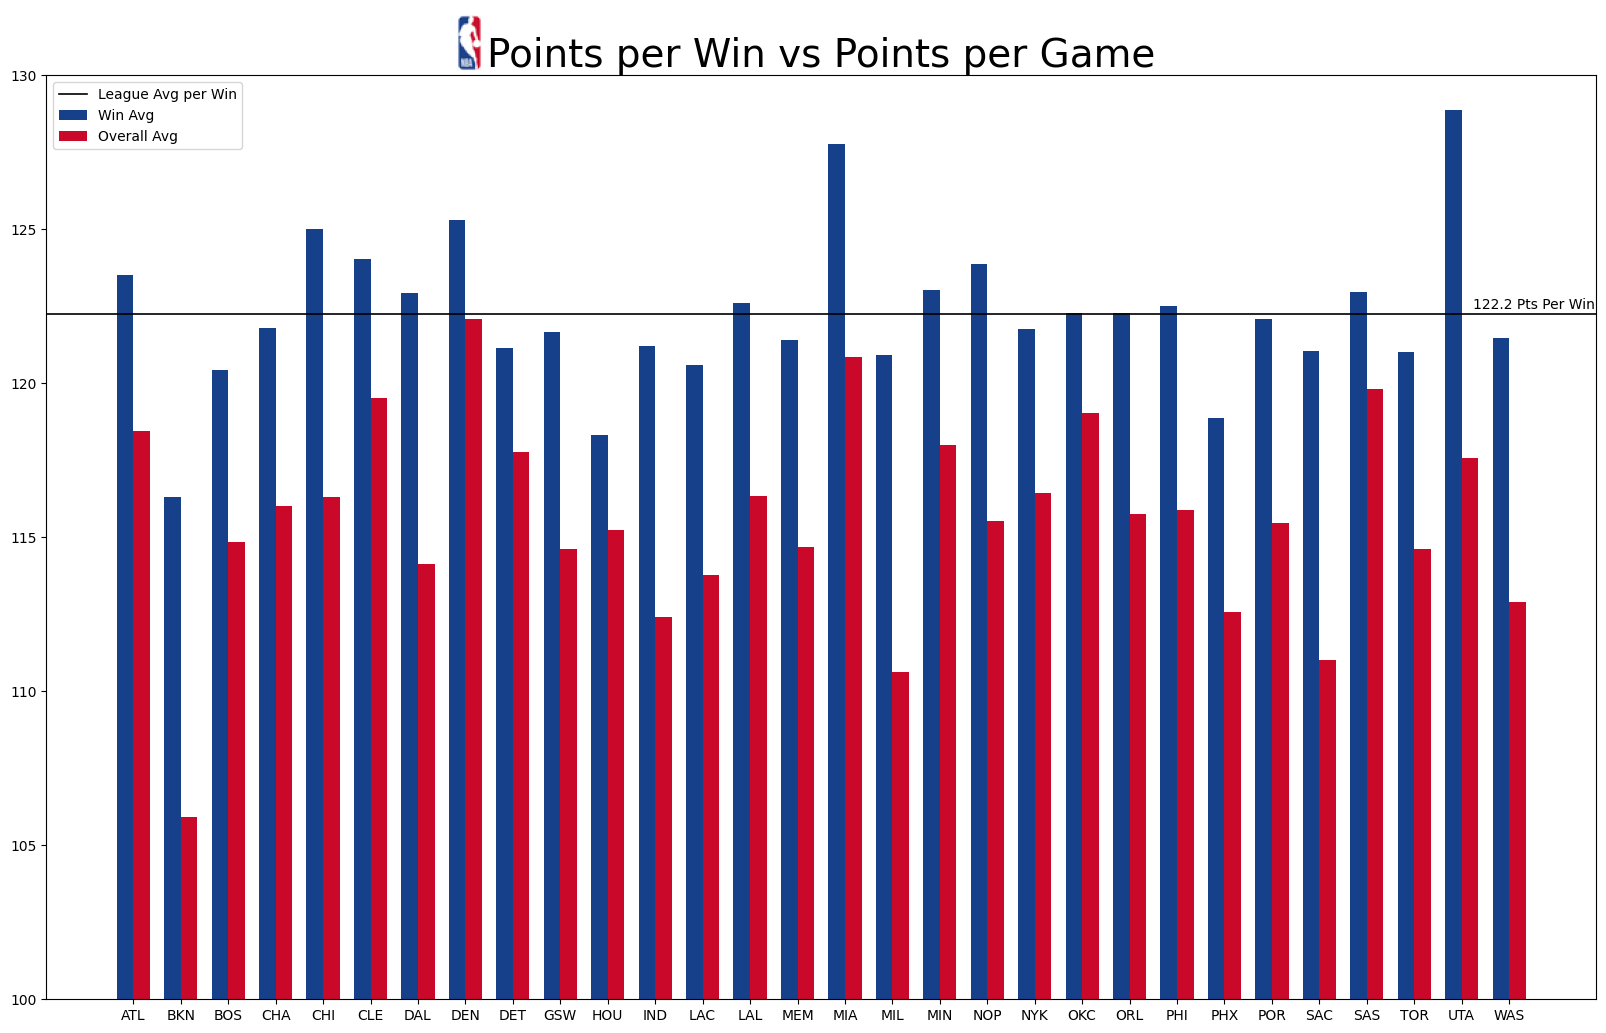

In [50]:
teams = list(overall_avg['team'])
x = np.arange(len(teams))  # Numerical locations for labels
width = 0.35  # Width of each bar

# create a figure and axis to plot a bar graph
fig, ax = plt.subplots(figsize =(20, 12))
# create and object for when plotting bar graph so that it can be looped through later. Bar graph consist of team and 'p_diff' and ronuded 2 places.
#bars_win = ax.bar(wins_agg['teams'], round(wins_agg['points'], 2), label = "Win Avg") # color = '#17408B'
#bars_ovr = ax.bar(overall_avg['TEAM_ABBREVIATION'], round(overall_avg['points'], 2), label = "Overall Avg")

bars_win = ax.bar(x - width/2, wins_agg['points'], width, label = "Win Avg", color='#17408B')
bars_ovr = ax.bar(x + width/2, overall_avg['points'], width, label = "Overall Avg", color='#C9082A')

# league_win_avg = sum(wins_agg['points'])/len(wins_agg['points'])

ax.set_ylim(100,130)
plt.title("Points per Win vs Points per Game", fontsize = 28)
ax.set_xticks(x)
ax.set_xticklabels(teams)
plt.axhline(league_win_avg, color='black', linewidth=1.2, label = 'League Avg per Win') # Add a line at League Average points for wins for clarity
ax.annotate(
    text=f"{round(league_win_avg,1)} Pts Per Win", 
    xy=(0.96, league_win_avg), 
    xycoords=('axes fraction', 'data'),
    xytext=(0, 2), 
    textcoords='offset points',
    color='black', 
    ha='center', 
    va='bottom'
)
plt.legend()
title_xy = ax.title.get_position()
plot_nba_logo(ax,title_xy)
plt.savefig('plots/points_per_win.png') # save figure off as a .png
plt.show()

In [8]:
def win_pct_win_avg(team: str, points_data: pd.DataFrame, ovr_data: pd.DataFrame)->Tuple[float,int,str]:
    win_avg = points_data.loc[points_data['team']==team, ['win_points']].values[0][0]
    avg_floor = floor(win_avg)

    games:pd.DataFrame = ovr_data.loc[(ovr_data['team'] == team) & (ovr_data['points'] >= avg_floor)]
    games_wins = games.loc[games['WL']=='W']
    num_wins = len(games_wins['WL'])
    num_games = len(games['WL'])
    pct = round(num_wins/num_games, 3)
    record = f"{num_wins}-{num_games-num_wins}"
    return pct, avg_floor, record

### Utah's Win Performance

0.706 128 12-5
    team      gameid  opp WL  points home/away  opp_score
35   UTA  0022501181  MEM  W     147      home        101
375  UTA  0022501014  MIL  W     128      home         96
535  UTA  0022500934  GSW  W     119      home        116
599  UTA  0022500900  WAS  W     122      away        112
844  UTA  0022500786  SAC  W     121      home         93


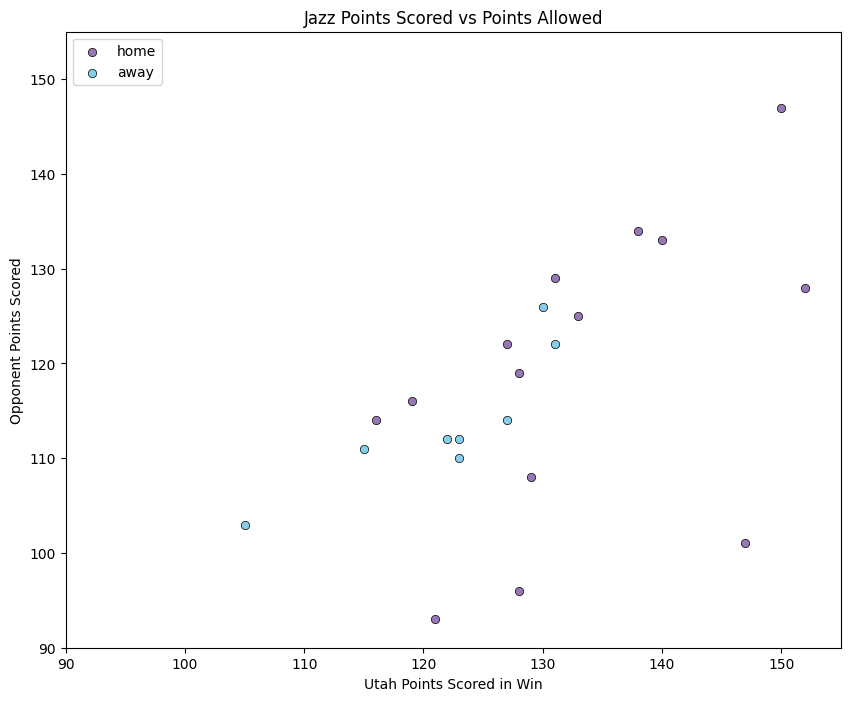

In [9]:
## FINDING WIN PERCENTAGE AT CERTAIN POINTS
pct, win_avg, record = win_pct_win_avg('UTA', points_compare, game_stats)
print(pct, win_avg, record)
## PLOTTING THE DATA

uta_wins = game_stats[(game_stats['team']== 'UTA') & (game_stats['WL'] == 'W')]
print(uta_wins.head())

mt_purp = '#9678b6'
sky_blue = '#87CEEB'
colors = [mt_purp if x == 'home' else sky_blue for x in uta_wins['home/away']]
uta_home = uta_wins[uta_wins['home/away'] == 'home']
uta_away = uta_wins[uta_wins['home/away'] == 'away']


fig2, ax2 = plt.subplots(figsize =(10, 8))
# plt.scatter(uta_wins['points'], uta_wins['opp_score'], color=colors)
scat_home = plt.scatter(uta_home['points'], uta_home['opp_score'], color=mt_purp, edgecolors='black', linewidths=0.5)
scat_away = plt.scatter(uta_away['points'], uta_away['opp_score'], color=sky_blue, edgecolors='black', linewidths=0.5)
plt.title('Jazz Points Scored vs Points Allowed')
ax2.set_xlabel("Utah Points Scored in Win")
ax2.set_ylabel("Opponent Points Scored")
ax2.set_xlim(90, 155)
ax2.set_ylim(90, 155)
plt.legend(['home', 'away'], loc='upper left')
plt.savefig('plots/uta_wins_scatter') # save figure off as a .png
plt.show()

### Brooklyn's Win Performance

0.688 116 11-5
    team      gameid  opp WL  points home/away  opp_score
93   BKN  0022501150  MIL  W      96      home         90
134  BKN  0022501133  WAS  W     121      home        115
237  BKN  0022501084  SAC  W     116      home         99
543  BKN  0022500932  MEM  W     126      home        115
573  BKN  0022500916  DET  W     107      away        105


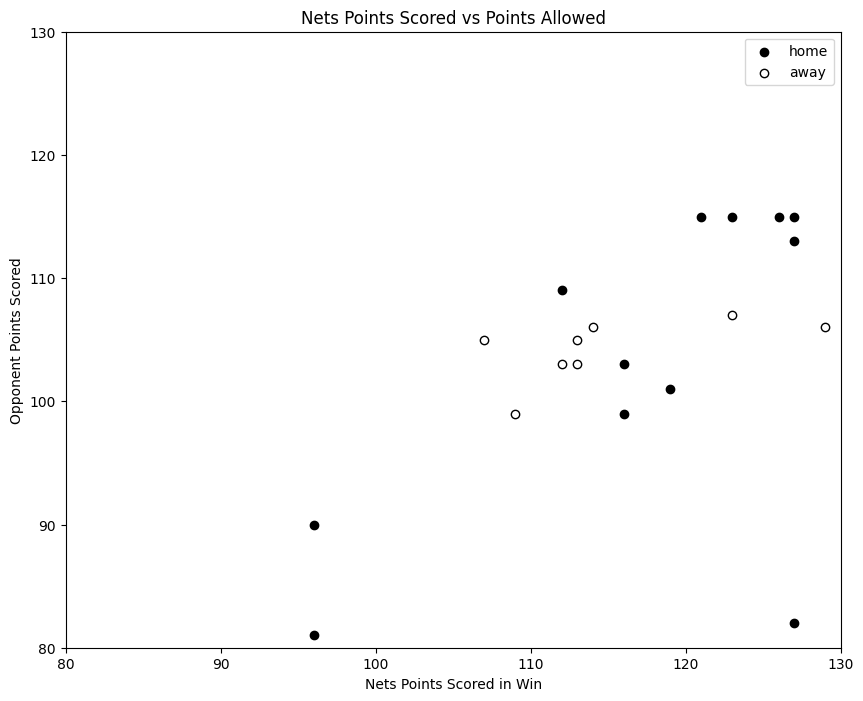

In [10]:
## FINDING WIN PERCENTAGE AT CERTAIN POINTS
pct, win_avg, record = win_pct_win_avg('BKN', points_compare, game_stats)
print(pct, win_avg, record)

## PLOTTING THE DATA
bkn_wins = game_stats[(game_stats['team']== 'BKN') & (game_stats['WL'] == 'W')]
print(bkn_wins.head())

bkn_home = bkn_wins[bkn_wins['home/away'] == 'home']
bkn_away = bkn_wins[bkn_wins['home/away'] == 'away']


fig3, ax3 = plt.subplots(figsize =(10, 8))
# plt.scatter(uta_wins['points'], uta_wins['opp_score'], color=colors)
scat_home = plt.scatter(bkn_home['points'], bkn_home['opp_score'], color='black')
scat_away = plt.scatter(bkn_away['points'], bkn_away['opp_score'], color='white', edgecolors='black')
plt.title('Nets Points Scored vs Points Allowed')
ax3.set_xlabel("Nets Points Scored in Win")
ax3.set_ylabel("Opponent Points Scored")
ax3.set_xlim(80, 130)
ax3.set_ylim(80, 130)
plt.legend(['home', 'away'])
plt.savefig('plots/bkn_wins_scatter') # save figure off as a .png
plt.show()

### OKC's Win Performance

1.0 122 36-0
    team      gameid  opp WL  points home/away  opp_score
74   OKC  0022501163  LAC  W     128      away        110
99   OKC  0022501155  LAL  W     123      away         87
121  OKC  0022501139  UTA  W     146      home        111
164  OKC  0022501116  LAL  W     139      home         96
208  OKC  0022501097  DET  W     114      home        110


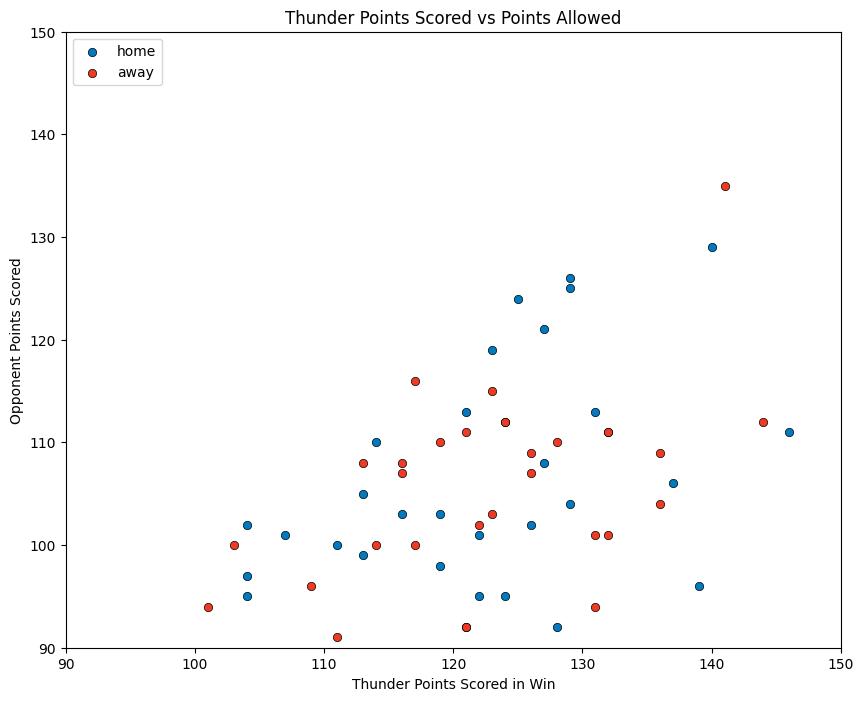

In [11]:
## FINDING WIN PERCENTAGE AT CERTAIN POINTS
pct, win_avg, record = win_pct_win_avg('OKC', points_compare, game_stats)
print(pct, win_avg, record)
## PLOTTING THE DATA

okc_wins = game_stats[(game_stats['team']== 'OKC') & (game_stats['WL'] == 'W')]
print(okc_wins.head())

okc_home = okc_wins[okc_wins['home/away'] == 'home']
okc_away = okc_wins[okc_wins['home/away'] == 'away']

thunder_blue = '#007AC1'
sunset = '#EF3B24'

fig5, ax5 = plt.subplots(figsize =(10, 8))
# plt.scatter(uta_wins['points'], uta_wins['opp_score'], color=colors)
scat_home = plt.scatter(okc_home['points'], okc_home['opp_score'], color=thunder_blue, edgecolors='black', linewidths=0.5)
scat_away = plt.scatter(okc_away['points'], okc_away['opp_score'], color=sunset, edgecolors='black', linewidths=0.5)
plt.title('Thunder Points Scored vs Points Allowed')
ax5.set_xlabel("Thunder Points Scored in Win")
ax5.set_ylabel("Opponent Points Scored")
ax5.set_xlim(90, 150)
ax5.set_ylim(90, 150)
plt.legend(['home', 'away'], loc='upper left')
plt.savefig('plots/okc_wins_scatter') # save figure off as a .png
plt.show()

## Point Average Differentials vs Win Percentage

[  6.1656371  130.87012987]
(0.5, 1.0)


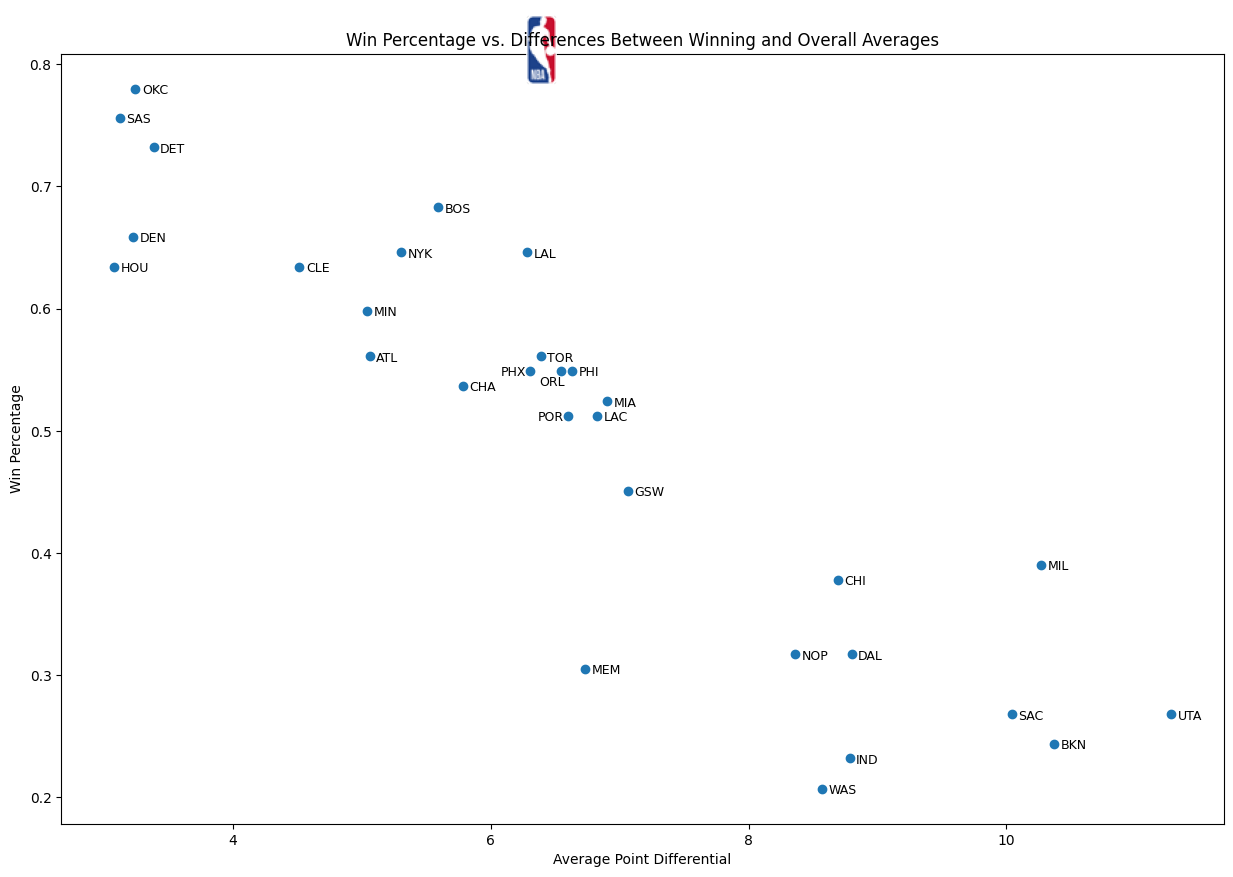

In [12]:
labels = list(points_compare['team'])
p_diff = list(points_compare['p_diff'])
win_pct = list(points_compare['win_pct'])
#print(labels)
fig4, ax4 = plt.subplots(figsize =(15,10))
# plt.scatter(points_compare['win_pct'], points_compare['p_diff'])
plt.scatter(p_diff, win_pct)
plt.title('Win Percentage vs. Differences Between Winning and Overall Averages')
ax4.set_ylabel("Win Percentage")
ax4.set_xlabel("Average Point Differential")

for i, label in enumerate(labels):
    # x+0.2 offsets the text horizontally to avoid overlapping the point
    if label == 'POR' or label == 'PHX':
        plt.text(p_diff[i] - 0.23, win_pct[i], label, fontsize=9, verticalalignment='center_baseline')
    elif label == 'ORL':
        plt.text(p_diff[i] - 0.17, win_pct[i] -0.008, label, fontsize=9, verticalalignment='center_baseline')
    else:
        plt.text(p_diff[i] + 0.05, win_pct[i], label, fontsize=9, verticalalignment='center_baseline')
# 'top', 'bottom', 'center', 'baseline', 'center_baseline'
title_xy = ax4.title.get_position()
t = ax4.title
bbox = t.get_window_extent()
data_coords = ax.transData.inverted().transform((bbox.x0, bbox.y1))
print(data_coords)
print(ax4.title.get_position())
plot_nba_logo(ax4, title_xy) # plotting NBA logo next to title
plt.savefig('plots/win_pct_vs_avg_diff.png')
plt.show()